In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# cargar el archivo con el dataset
df_banca = pd.read_csv(r"C:\Users\tinke\Desktop\simulador empresarial\101125_dataset.csv", sep=';')

#### Tranformación df_banca

In [3]:
def age_groups(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - 'joven' : si la edad es menor o igual a 25
       - 'adulto_joven' : si la edad es menor o igual a 35
       - 'adulto'    : si la edad es menor o igual a 55
       - 'senior' : en el resto de rango de edades'''

    if x < 35:
        return '18-34'
    elif x < 45:
        return '35-44'
    elif x < 55:
        return '45-54'
    elif x < 65:
        return '55-64'
    elif x < 80:
        return '65-79'
    else:
        return '>79'
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df_banca['age_group'] = df_banca['age'].apply(age_groups)

# Verificacion de distribución
(df_banca['age_group'].value_counts()).round(2)

age_group
18-34    9096
35-44    7861
45-54    5177
55-64    3048
65-79     821
>79       173
Name: count, dtype: int64

In [4]:
def age_clusters(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - 'Generation Z y Millenials' : si la edad es menor a 35
       - 'Generation X' : si la edad es menor a 55
       - 'Baby Boomers' : si la edad es mayor o igual a 55
       '''

    if x < 35:
        return 'Generation Z y Millenials'
    elif x < 55:
        return 'Generation X'
    elif x >= 55:
        return 'Baby Boomers'
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df_banca['age_clusters'] = df_banca['age'].apply(age_clusters)

# Verificacion de distribución
(df_banca['age_clusters'].value_counts()).round(2)

age_clusters
Generation X                 13038
Generation Z y Millenials     9096
Baby Boomers                  4042
Name: count, dtype: int64

In [5]:
def simplify_job(job):

    '''     Clasifica cada valor dentro de una categoría nueva de empleos
       ----------
       Parámetro
       x : object - Ocupación de cada cliente.
       -------
       Retorna        
       Etiqueta de nueva catgorización de los empleos:
       - 'cuenta ajena' : si los valores son 'management', 'technician', 'administrative', 'services' y 'blue-collar'
       - 'cuenta propia' : si los valores son 'self-employed', 'entrepreneur'
       - 'jubilación' : si 'retired'
       - 'otros inactivos' : si los valores son 'student', 'housemaid'
       - 'desempleo' : si el valor es 'unemployed'
       '''
      
    job = str(job).lower().strip()
    if job in ['management', 'technician', 'administrative', 'services', 'blue-collar']:
        return 'cuenta ajena'
    elif job in ['unemployed']:
        return 'desempleo'
    elif job in ['self-employed', 'entrepreneur']:
         return 'cuenta propia'
    elif job in ['retired']:
        return 'jubilación'
    else:
        return 'otros inactivos'

    
# Aplicar la función y crear una columna nueva job_cat
df_banca['job_cat'] = df_banca['job'].apply(simplify_job)

# Verificacion de distribución
(df_banca['job_cat'].value_counts(normalize=True)).round(2)

job_cat
cuenta ajena       0.77
jubilación         0.07
cuenta propia      0.07
otros inactivos    0.06
desempleo          0.03
Name: proportion, dtype: float64

In [6]:
# Education

def simplify_edu(edu):

    '''     Cambia el valor de la columna 'education' renombrándo cada uno
       ----------
       Parámetro
       x : object - nivel educativo.
       -------
       Retorna        
       Etiqueta nueva de los niveles educativos:
       - 'Primaria' : si el valor es 'primary'
       - 'Secundaria' : si el valor es 'secondary'
       - 'Universitaria'  : si el valor es 'tertiary'
    '''
    
    edu = str(edu).lower()
    if 'primary' in edu:
        return 'Primaria'
    elif 'secondary' in edu:
        return 'Secundaria'
    else:
        'tertiary' in edu or 'university' in edu
        return 'Universitaria'

df_banca['education_level'] = df_banca['education'].apply(simplify_edu)

# Verificacion de la distribución
(df_banca['education_level'].value_counts(normalize=True)).round(2)

education_level
Secundaria       0.52
Universitaria    0.34
Primaria         0.14
Name: proportion, dtype: float64

### clusters

In [7]:
# Seleccionar las variables para el clustering
demo_vars = ['age_clusters', 'job_cat', 'education_level', 'marital']
df_cat = df_banca[demo_vars].copy()

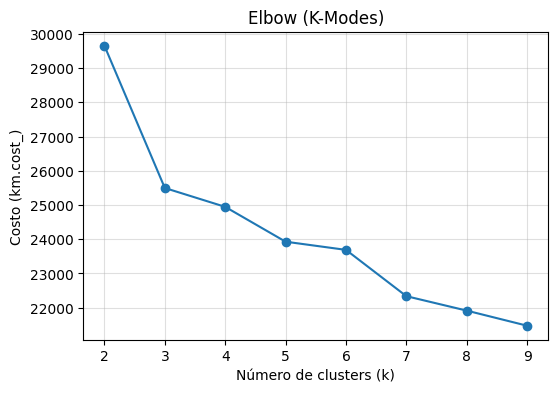

In [8]:
# Metodo de codo (Elbow) para KModes para encontar el número óptimo de clusters
K = range(2, 10)
cost = []

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42) # se pueden usar init= Cao o Huang
    km.fit_predict(df_cat)
    cost.append(km.cost_)

plt.figure(figsize=(6,4))
plt.plot(K, cost, marker='o')
plt.title('Elbow (K-Modes)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Costo (km.cost_)')
plt.grid(alpha=0.4)
plt.show()


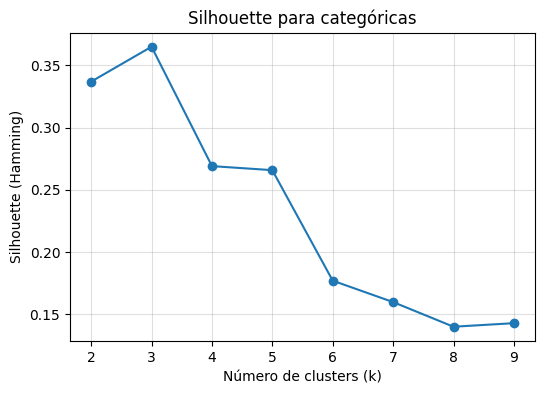

In [9]:
# Codificar variables categóricas como números para calcular silhouette (métrica Hamming), encontrar número óptimo de clusters
df_encoded = df_cat.copy()
for col in df_encoded.columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

sil_scores = []
K = range(2, 10)

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    clusters = km.fit_predict(df_cat)
    score = silhouette_score(df_encoded, clusters, metric='hamming')
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette para categóricas')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette (Hamming)')
plt.grid(alpha=0.4)
plt.show()


## kmode algoritmo

In [10]:
# Definir como número de clusters 3 
kmode = KModes(n_clusters=3, init = "Cao", n_init = 10, verbose=1, random_state=42) # se puede probar con Cao en init o Huang
clusters = kmode.fit_predict(df_cat)
clusters

# Añadir en df original la columna con los clusters generados
df_banca['Cluster'] = clusters 
df_cat['Cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1481, cost: 25496.0


In [11]:
cluster_modes = pd.DataFrame(kmode.cluster_centroids_, columns=demo_vars)

cluster_modes.index = [f'Cluster_{i}' for i in range(len(cluster_modes))]

df_cat['Cluster'] = clusters
print(cluster_modes)

                        age_clusters       job_cat education_level  marital
Cluster_0               Generation X  cuenta ajena      Secundaria  married
Cluster_1  Generation Z y Millenials  cuenta ajena   Universitaria   single
Cluster_2               Baby Boomers    jubilación        Primaria  married


In [12]:
df_banca.to_csv(r"C:\Users\tinke\Desktop\simulador empresarial\banca_actualizado.csv",sep=";",index=False)